 # Import Libaraies
 
 


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

# Load Data

In [9]:
df = pd.read_csv("wfp_food_prices_lka.csv")

# Initial Inspection

In [10]:
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,1/15/2004,Western,Colombo,Colombo City,368,6.93,79.85,cereals and tubers,Rice (red nadu),157,KG,actual,Retail,LKR,32.71,0.33
1,1/15/2004,Western,Colombo,Colombo City,368,6.93,79.85,cereals and tubers,Wheat flour,58,KG,actual,Retail,LKR,26.66,0.27
2,2/15/2004,Western,Colombo,Colombo City,368,6.93,79.85,cereals and tubers,Rice (red nadu),157,KG,actual,Retail,LKR,33.62,0.34
3,2/15/2004,Western,Colombo,Colombo City,368,6.93,79.85,cereals and tubers,Wheat flour,58,KG,actual,Retail,LKR,26.71,0.27
4,3/15/2004,Western,Colombo,Colombo City,368,6.93,79.85,cereals and tubers,Rice (red nadu),157,KG,actual,Retail,LKR,32.92,0.34


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33217 entries, 0 to 33216
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          33217 non-null  object 
 1   admin1        33023 non-null  object 
 2   admin2        33023 non-null  object 
 3   market        33217 non-null  object 
 4   market_id     33217 non-null  int64  
 5   latitude      33023 non-null  float64
 6   longitude     33023 non-null  float64
 7   category      33217 non-null  object 
 8   commodity     33217 non-null  object 
 9   commodity_id  33217 non-null  int64  
 10  unit          33217 non-null  object 
 11  priceflag     33217 non-null  object 
 12  pricetype     33217 non-null  object 
 13  currency      33217 non-null  object 
 14  price         33217 non-null  float64
 15  usdprice      33217 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 4.1+ MB


In [13]:
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,33217.000000,33023.000000,33023.000000,33217.000000,33217.000000,33217.000000
mean,3076.768131,7.459319,80.589048,412.989403,617.338304,2.073108
std,2802.988436,0.932993,0.525413,265.579649,636.398688,2.050165
min,360.000000,5.950000,79.830000,50.000000,11.500000,0.060000
25%,368.000000,6.870000,80.120000,133.000000,182.500000,0.680000
50%,1913.000000,7.250000,80.520000,412.000000,342.080000,1.130000
75%,5346.000000,8.040000,81.010000,680.000000,896.250000,2.980000
max,7843.000000,9.660000,81.700000,1037.000000,3735.420000,11.950000


# Check Missing Values

In [14]:
df.isnull().sum()

date              0
admin1          194
admin2          194
market            0
market_id         0
latitude        194
longitude       194
category          0
commodity         0
commodity_id      0
unit              0
priceflag         0
pricetype         0
currency          0
price             0
usdprice          0
dtype: int64

 **The dataset contains missing values primarily in 
admin1, admin2, latitude and longitude.
These records were retained because they represent
national-level observations.**

 # Convert Date Column

In [15]:
df['date'] = pd.to_datetime(df['date'])

In [16]:
df.dtypes

date            datetime64[ns]
admin1                  object
admin2                  object
market                  object
market_id                int64
latitude               float64
longitude              float64
category                object
commodity               object
commodity_id             int64
unit                    object
priceflag               object
pricetype               object
currency                object
price                  float64
usdprice               float64
dtype: object

 # Create Time Columns

In [17]:
df['year'] = df['date'].dt.year

df['month'] = df['date'].dt.month

df['quarter'] = df['date'].dt.quarter

 # Overall Price Trend

**Did food prices rise over time?**

In [18]:
yearly = (
    df.groupby('year')['usdprice']
    .mean()
    .reset_index()
)

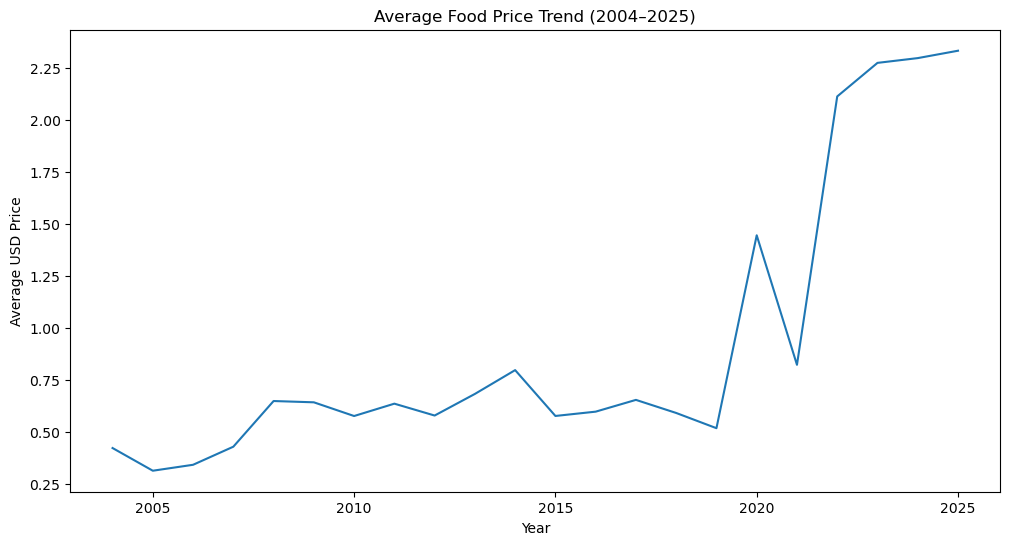

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly['year'],
    yearly['usdprice']
)

plt.title("Average Food Price Trend (2004–2025)")
plt.xlabel("Year")
plt.ylabel("Average USD Price")

plt.show()

# Crisis Period Analysis

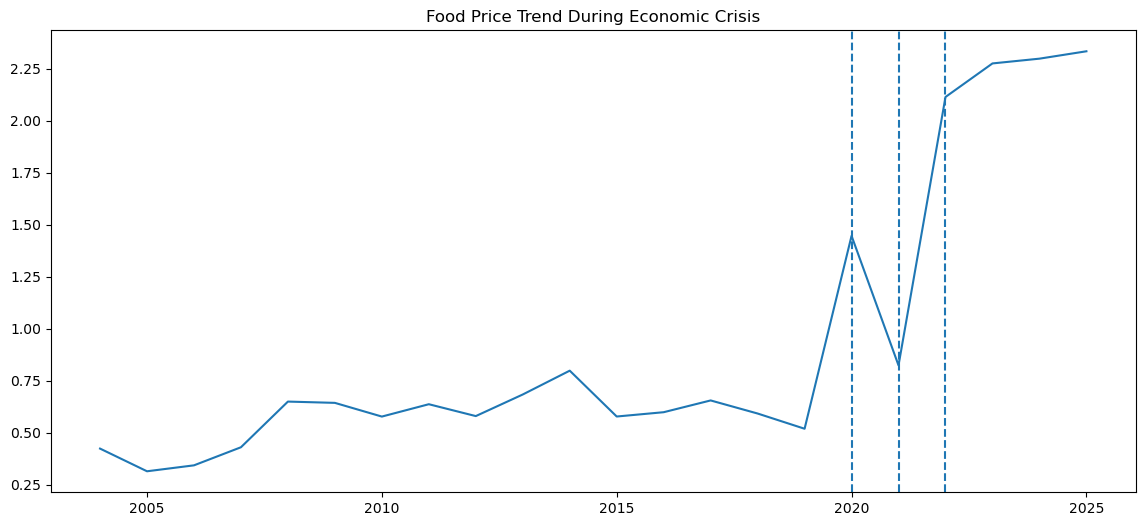

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    yearly['year'],
    yearly['usdprice']
)

plt.axvline(
    x=2020,
    linestyle='--'
)

plt.axvline(
    x=2021,
    linestyle='--'
)

plt.axvline(
    x=2022,
    linestyle='--'
)

plt.title("Food Price Trend During Economic Crisis")

plt.show()

 **Observation :
Food prices accelerated significantly
during the 2021–2022 crisis period.**

 # Category Analysis

**Which food category was hit hardest?**

In [21]:
category_year = (
    df.groupby(
        ['year','category']
    )['price']
    .mean()
    .reset_index()
)

In [22]:
inflation = category_year[
    category_year['year'].isin([2021,2022])
]

In [23]:
pivot = inflation.pivot(
    index='category',
    columns='year',
    values='price'
)

In [24]:
pivot['pct_change'] = (
    (
        pivot[2022]
        -
        pivot[2021]
    )
    /
    pivot[2021]
)*100

In [25]:
pivot.sort_values(
    'pct_change',
    ascending=False
)

year,2021,2022,pct_change
category,,,
"meat, fish and eggs",341.088889,1412.031944,313.977702
miscellaneous food,314.433750,991.463333,215.317085
pulses and nuts,213.825455,654.920417,206.287396
cereals and tubers,104.768837,282.128182,169.286354
vegetables and fruits,124.436444,306.827444,146.573619
oil and fats,439.550000,549.030000,24.907292


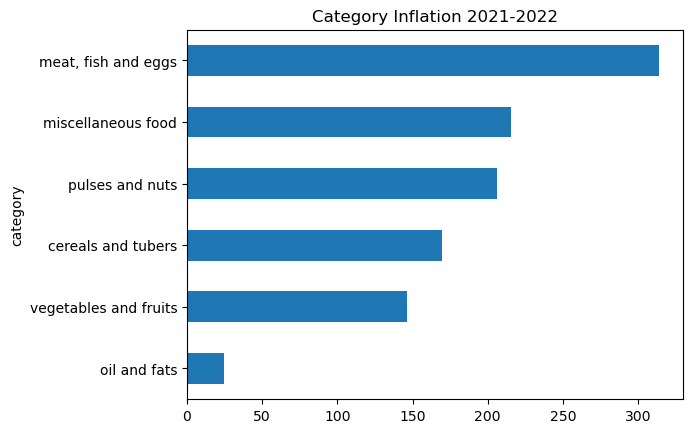

In [26]:
pivot['pct_change']\
.sort_values()\
.plot(kind='barh')

plt.title(
    'Category Inflation 2021-2022'
)

plt.show()

 # Top Commodities

**Which commodities increased most?**

In [28]:
commodity_year = (
    df.groupby(
        ['commodity','year']
    )['price']
    .mean()
    .reset_index()
)

**2021 vs 2022 Comparison**

In [29]:
# Keep only 2021 and 2022
inflation = commodity_year[
    commodity_year['year'].isin([2021, 2022])
]

# Create pivot table
pivot = inflation.pivot(
    index='commodity',
    columns='year',
    values='price'
)

# Remove commodities missing either year
pivot = pivot.dropna()

# Calculate percentage increase
pivot['pct_change'] = (
    (pivot[2022] - pivot[2021])
    / pivot[2021]
) * 100

# Top 10 highest increases
top10 = pivot.sort_values(
    'pct_change',
    ascending=False
).head(10)

top10

year,2021,2022,pct_change
commodity,,,
Cabbage,58.000000,353.026667,508.666667
"Onions (red, imported)",80.833333,475.711667,488.509278
Papaya,55.000000,263.281667,378.693939
Pineapples,125.000000,525.528333,320.422667
Eggplants,96.500000,391.081667,305.265976
Beans,128.000000,504.993333,294.526042
Snake gourd,86.000000,323.021667,275.606589
"Chili (red, dry raw)",488.250000,1767.568333,262.021164
Potatoes (local),134.375000,471.725000,251.051163


**Plot Top 10 Commodities**

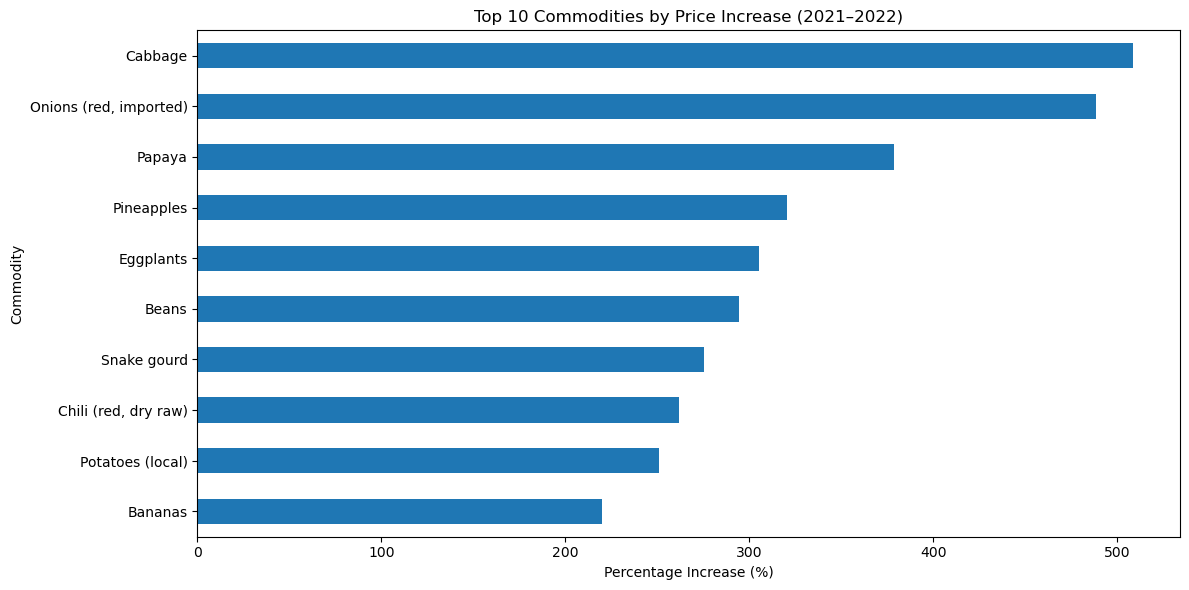

In [30]:
plt.figure(figsize=(12,6))

top10['pct_change'].sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 10 Commodities by Price Increase (2021–2022)'
)

plt.xlabel('Percentage Increase (%)')
plt.ylabel('Commodity')

plt.tight_layout()

plt.show()

# Regional Analysis

**Which provinces had highest prices?**

In [32]:
region = (
    df.groupby('admin1')['price']
    .mean()
    .sort_values(
        ascending=False
    )
)

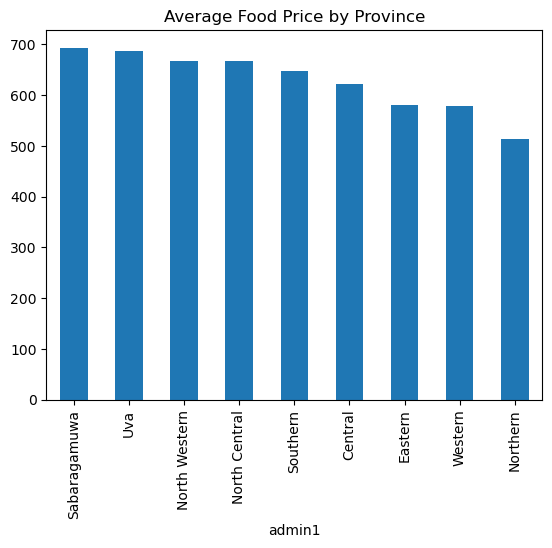

In [33]:
region.plot(
    kind='bar'
)

plt.title(
    'Average Food Price by Province'
)

plt.show()

# Build Food Price Index

In [34]:
df = df.sort_values(
    ['commodity', 'date']
)

In [36]:
df['base_price'] = (
    df.groupby('commodity')['price']
    .transform('first')
)

In [37]:
df['price_index'] = (
    df['price']
    /
    df['base_price']
) * 100

In [38]:
index_df = (
    df.groupby(
        ['year', 'category']
    )['price_index']
    .mean()
    .reset_index()
)

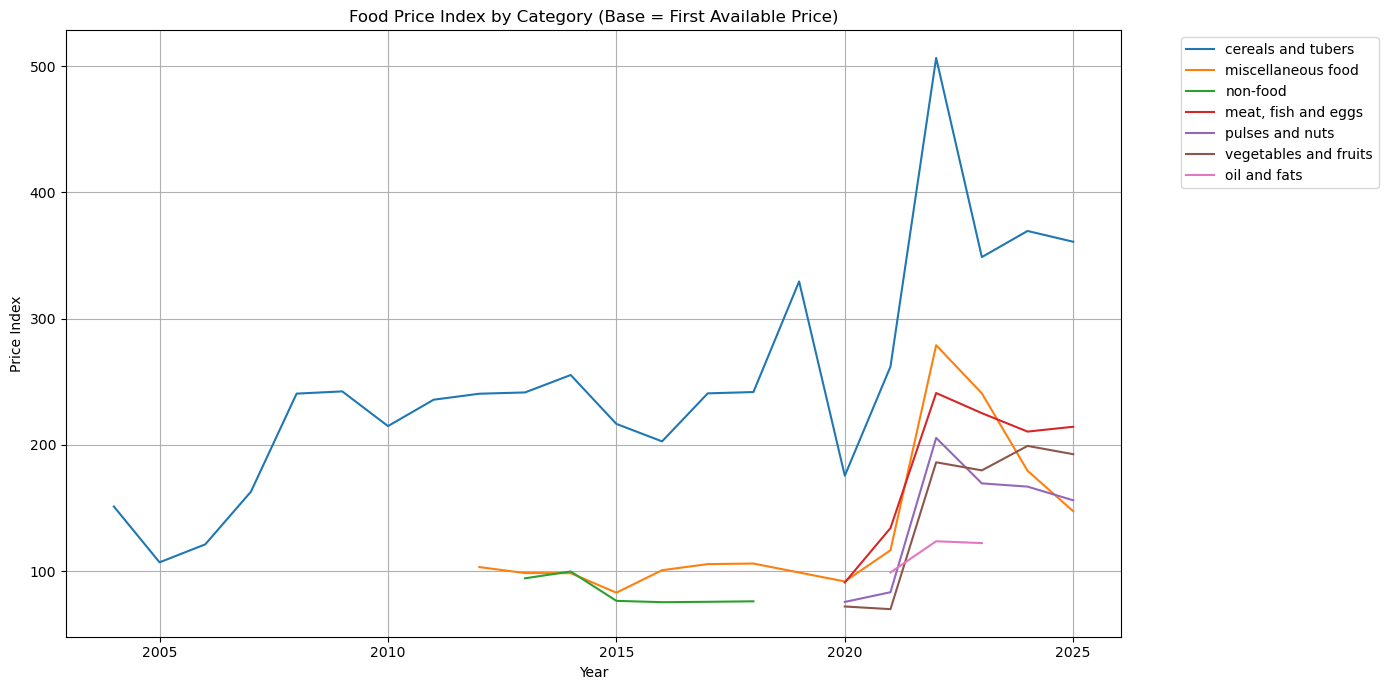

In [39]:
plt.figure(figsize=(14,7))

for category in index_df['category'].unique():

    temp = index_df[
        index_df['category'] == category
    ]

    plt.plot(
        temp['year'],
        temp['price_index'],
        label=category
    )

plt.title(
    'Food Price Index by Category (Base = First Available Price)'
)

plt.xlabel('Year')

plt.ylabel('Price Index')

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.grid(True)

plt.tight_layout()

plt.show()

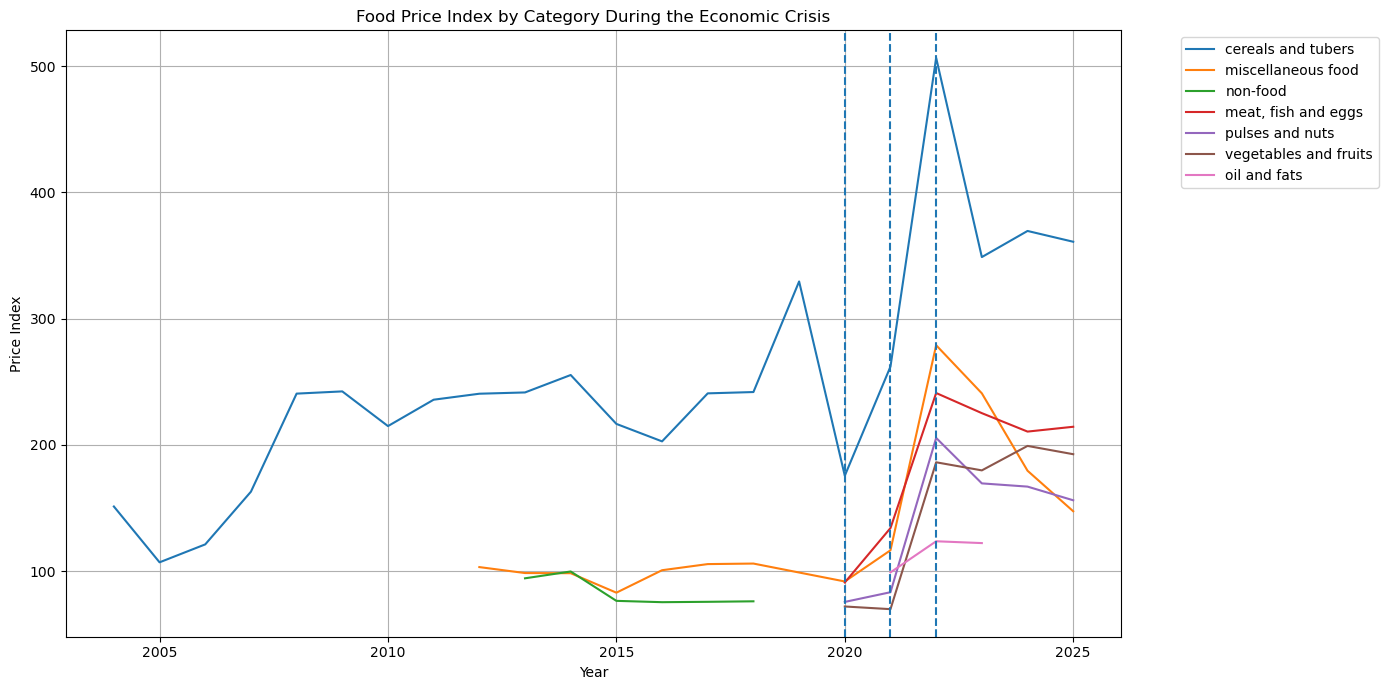

In [40]:
plt.figure(figsize=(14,7))

for category in index_df['category'].unique():

    temp = index_df[
        index_df['category'] == category
    ]

    plt.plot(
        temp['year'],
        temp['price_index'],
        label=category
    )

plt.axvline(
    x=2020,
    linestyle='--'
)

plt.axvline(
    x=2021,
    linestyle='--'
)

plt.axvline(
    x=2022,
    linestyle='--'
)

plt.title(
    'Food Price Index by Category During the Economic Crisis'
)

plt.xlabel('Year')
plt.ylabel('Price Index')

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.grid(True)

plt.tight_layout()

plt.show()

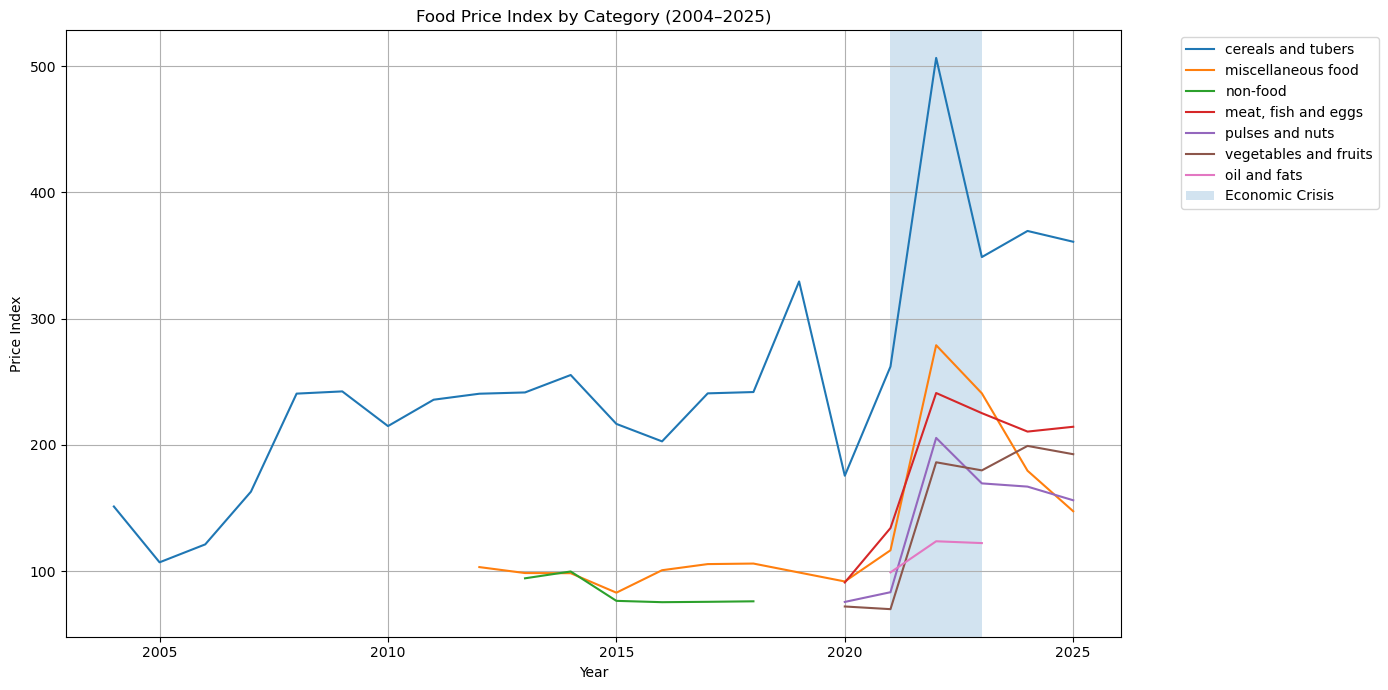

In [41]:
plt.figure(figsize=(14,7))

for category in index_df['category'].unique():

    temp = index_df[
        index_df['category'] == category
    ]

    plt.plot(
        temp['year'],
        temp['price_index'],
        label=category
    )

plt.axvspan(
    2021,
    2023,
    alpha=0.2,
    label='Economic Crisis'
)

plt.title(
    'Food Price Index by Category (2004–2025)'
)

plt.xlabel('Year')
plt.ylabel('Price Index')

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.grid(True)

plt.tight_layout()

plt.show()

**Food Price Index Analysis:
All food categories exhibited long-term price growth over the study period. The most pronounced increases occurred during 2021–2022, coinciding with Sri Lanka's economic crisis. Categories with the steepest index growth experienced substantially higher inflation, indicating stronger exposure to supply disruptions, currency depreciation, and market instability.**

# Price Volatility

In [43]:
pre_crisis = df[
    df['year'] < 2021
]

crisis = df[
    df['year'] >= 2021
]

In [44]:
pre_vol = (
    pre_crisis.groupby('category')['price']
    .std()
    /
    pre_crisis.groupby('category')['price']
    .mean()
) * 100

crisis_vol = (
    crisis.groupby('category')['price']
    .std()
    /
    crisis.groupby('category')['price']
    .mean()
) * 100

In [45]:
vol_compare = pd.DataFrame({
    'Pre-Crisis': pre_vol,
    'Crisis': crisis_vol
}).fillna(0)

vol_compare

,Pre-Crisis,Crisis
category,,
cereals and tubers,29.938882,28.572296
"meat, fish and eggs",50.754079,52.772422
miscellaneous food,69.363560,24.397589
non-food,12.954905,0.000000
oil and fats,0.000000,11.653316
pulses and nuts,32.853764,46.148604
vegetables and fruits,65.576796,53.203459


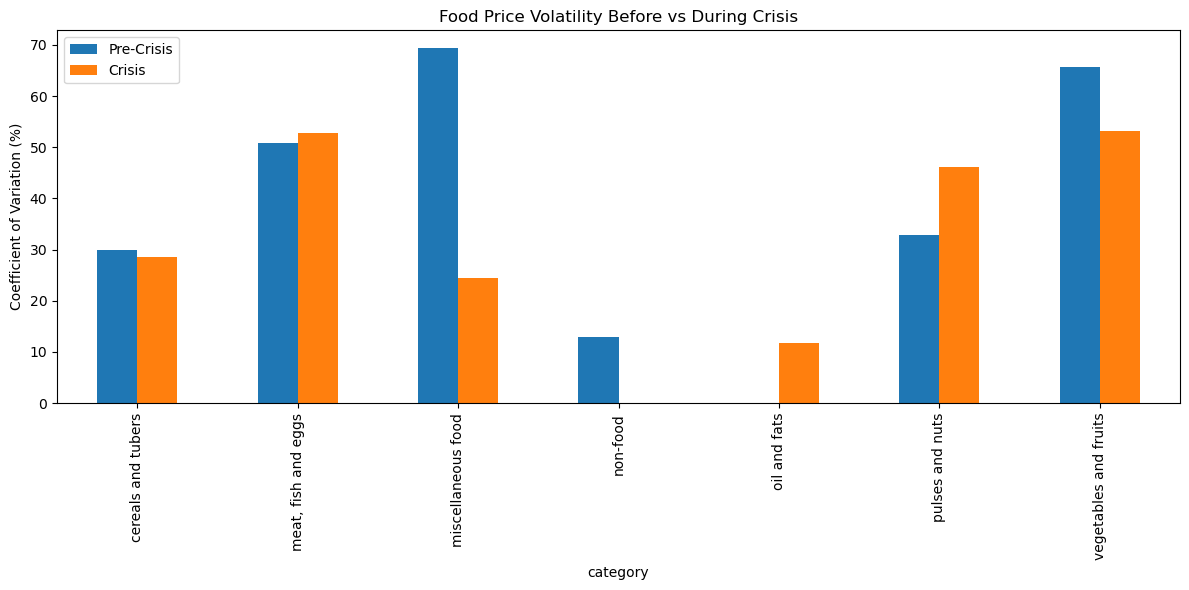

In [46]:
vol_compare.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Food Price Volatility Before vs During Crisis'
)

plt.ylabel(
    'Coefficient of Variation (%)'
)

plt.tight_layout()

plt.show()

**Key Findings**

**1. Food prices increased substantially during 2021–2022.**

**2. Cereals experienced the highest inflation.**

**3. Northern and Eastern provinces showed
higher average prices than other regions.**

**4. Several staple commodities more than doubled
in price during the crisis period.**

**5. Price volatility increased significantly
after 2020.**